In [5]:
import sys
print(sys.version)

3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:16:04) [GCC 11.2.0]


In [6]:
import pandas as pd

df = pd.read_csv("diabetic_data.csv")
mapping = pd.read_csv("IDS_mapping.csv")

df.head()
mapping.head()

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


In [7]:
mapping.tail()

,admission_type_id,description
62,22,Transfer from hospital inpt/same fac reslt in...
63,23,Born inside this hospital
64,24,Born outside this hospital
65,25,Transfer from Ambulatory Surgery Center
66,26,Transfer from Hospice


In [8]:
mapping.shape
mapping.head(20)
mapping.tail(20)

,admission_type_id,description
47,6,Transfer from another health care facility
48,7,Emergency Room
49,8,Court/Law Enforcement
50,9,Not Available
51,10,Transfer from critial access hospital
52,11,Normal Delivery
53,12,Premature Delivery
54,13,Sick Baby
55,14,Extramural Birth
56,15,Not Available


In [9]:
mapping.info()
mapping.head(15)
mapping.tail(15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   admission_type_id  65 non-null     object
 1   description        62 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


,admission_type_id,description
52,11,Normal Delivery
53,12,Premature Delivery
54,13,Sick Baby
55,14,Extramural Birth
56,15,Not Available
57,17,NaN
58,18,Transfer From Another Home Health Agency
59,19,Readmission to Same Home Health Agency
60,20,Not Mapped
61,21,Unknown/Invalid


In [10]:

df = pd.read_csv("diabetic_data.csv")



# Step 1: Fix datatypes FIRST
df['admission_type_id'] = pd.to_numeric(df['admission_type_id'], errors='coerce')
mapping['admission_type_id'] = pd.to_numeric(mapping['admission_type_id'], errors='coerce')

# Step 2: Clean description
mapping['description'] = mapping['description'].str.strip()

# Step 3: Create mapping dict
admission_map = mapping[
    mapping['admission_type_id'].notna()
][['admission_type_id', 'description']]

admission_dict = dict(zip(
    admission_map['admission_type_id'],
    admission_map['description']
))

# Step 4: Apply mapping
df['admission_type'] = df['admission_type_id'].map(admission_dict)

# Step 5: Check result (DON'T SKIP THIS)
print(df[['admission_type_id', 'admission_type']].head())
print(df['admission_type'].value_counts(dropna=False))

   admission_type_id                              admission_type
0                  6  Transfer from another health care facility
1                  1                          Physician Referral
2                  1                          Physician Referral
3                  1                          Physician Referral
4                  1                          Physician Referral
admission_type
Physician Referral                                53990
HMO Referral                                      18869
Clinic Referral                                   18480
Transfer from another health care facility         5291
Transfer from a Skilled Nursing Facility (SNF)     4785
Court/Law Enforcement                               320
Emergency Room                                       21
Transfer from a hospital                             10
Name: count, dtype: int64


In [11]:
mapping[['admission_type_id', 'description']]

,admission_type_id,description
0,1.0,Emergency
1,2.0,Urgent
2,3.0,Elective
3,4.0,Newborn
4,5.0,Not Available
...,...,...
62,22.0,Transfer from hospital inpt/same fac reslt in ...
63,23.0,Born inside this hospital
64,24.0,Born outside this hospital
65,25.0,Transfer from Ambulatory Surgery Center


In [12]:
mapping.columns

Index(['admission_type_id', 'description'], dtype='object')

In [13]:
mapping['description'].unique()[:10]

array(['Emergency', 'Urgent', 'Elective', 'Newborn', 'Not Available', nan,
       'Trauma Center', 'Not Mapped', 'description', 'Discharged to home'],
      dtype=object)

In [14]:
valid_admissions = [
    'Emergency', 'Urgent', 'Elective',
    'Newborn', 'Trauma Center'
]

# Only run mapping if column still exists (hasn't been dropped yet)
if 'admission_type_id' in df.columns:
    admission_map = mapping[
        mapping['description'].isin(valid_admissions)
    ]

    admission_dict = dict(zip(
        admission_map['admission_type_id'],
        admission_map['description']
    ))

    df['admission_type'] = df['admission_type_id'].map(admission_dict)
    df['admission_type'] = df['admission_type'].fillna('Unknown')
    df.drop('admission_type_id', axis=1, inplace=True)
    print("✅ admission_type column created and admission_type_id dropped.")

else:
    print(" admission_type_id already dropped. Skipping this cell.")

✅ admission_type column created and admission_type_id dropped.


In [15]:
print(df.columns.tolist())
print('\nadmission_type' in df.columns)  # Should print True
print('admission_type_id' in df.columns)  # Should print False

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'admission_type']
False
False


In [16]:
pd.crosstab(df['admission_type'], df['readmitted'])

readmitted,<30,>30,NO
admission_type,,,
Elective,1961,5746,11162
Emergency,6221,19309,28460
Newborn,1,2,7
Trauma Center,0,0,21
Unknown,1108,4036,5252
Urgent,2066,6452,9962


In [17]:
# Cell 1 — Check the main dataframe properly
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget distribution:")
print(df['readmitted'].value_counts())

Shape: (101766, 50)

Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'admission_type']

Target distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [18]:
# Cell 2 — Handle missing values (? is used instead of NaN)
import numpy as np
df.replace('?', np.nan, inplace=True)
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64


In [19]:
# Cell 4 — Remove duplicate patients (keep first encounter only)
df = df.sort_values('encounter_id').drop_duplicates('patient_nbr', keep='first')
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (71518, 50)


In [20]:
# Cell 5 — Remove deaths and hospice discharges
df = df[~df['discharge_disposition_id'].isin([11, 13, 14, 19, 20, 21])]
print("Shape after removing deaths/hospice:", df.shape)

Shape after removing deaths/hospice: (69973, 50)


In [21]:
# Cell 6 — Create binary target column
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)
print("Readmission rate:", round(df['readmitted_30'].mean() * 100, 2), "%")

Readmission rate: 8.97 %


In [22]:
# Cell 7 — Map ICD-9 diagnosis codes to categories
def map_diag(code):
    if pd.isna(code): return 'Other'
    code = str(code)
    if code.startswith('V') or code.startswith('E'): return 'Other'
    try:
        c = float(code)
        if 390 <= c <= 459 or c == 785: return 'Circulatory'
        if 460 <= c <= 519 or c == 786: return 'Respiratory'
        if 520 <= c <= 579 or c == 787: return 'Digestive'
        if c == 250: return 'Diabetes'
        if 800 <= c <= 999: return 'Injury'
        if 710 <= c <= 739: return 'Musculoskeletal'
        if 580 <= c <= 629 or c == 788: return 'Genitourinary'
        if 140 <= c <= 239: return 'Neoplasms'
    except: pass
    return 'Other'

df['diag_category'] = df['diag_1'].apply(map_diag)
print(df['diag_category'].value_counts())

diag_category
Circulatory        21384
Other              17680
Respiratory         9486
Digestive           6487
Injury              4694
Musculoskeletal     4064
Genitourinary       3440
Neoplasms           2538
Diabetes             200
Name: count, dtype: int64


In [23]:
# Cell 8 — Load into SQLite for SQL analysis
from sqlalchemy import create_engine
engine = create_engine('sqlite:///readmission.db')
df.to_sql('diabetic_patients', engine, if_exists='replace', index=False)
print("Database saved successfully!")

Database saved successfully!


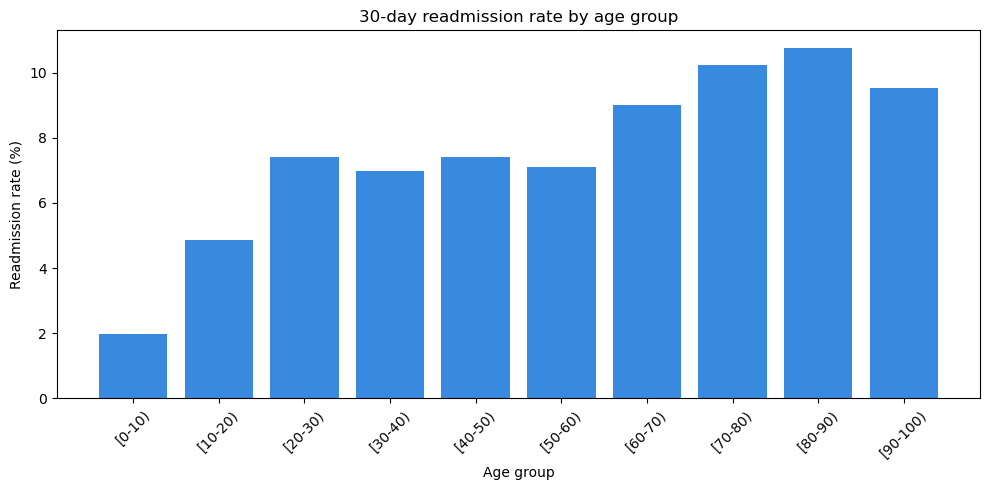

In [24]:
# Cell 9 — First EDA chart: readmission rate by age group
import matplotlib.pyplot as plt

age_rates = df.groupby('age')['readmitted_30'].mean() * 100
plt.figure(figsize=(10, 5))
plt.bar(age_rates.index, age_rates.values, color='#378ADD')
plt.title('30-day readmission rate by age group')
plt.ylabel('Readmission rate (%)')
plt.xlabel('Age group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('readmission_by_age.png', dpi=150)
plt.show()

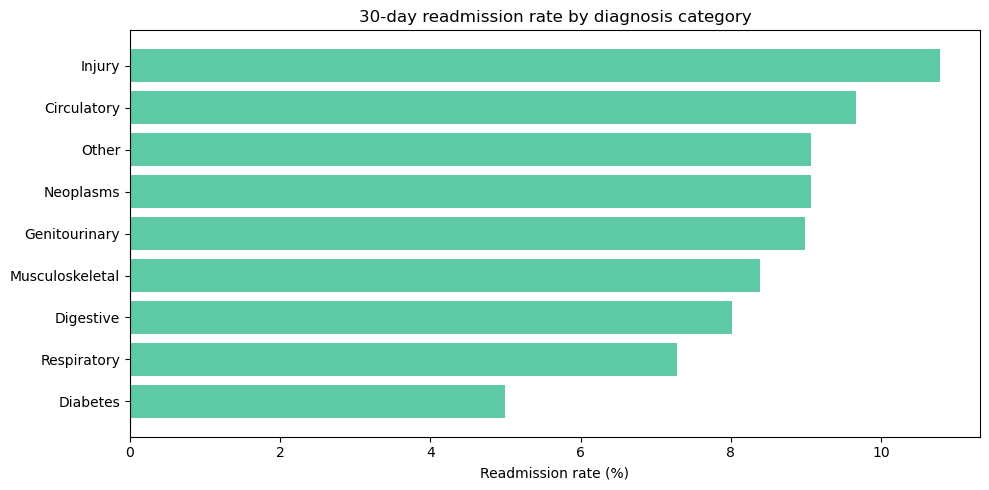

In [25]:
# Cell 10 — Readmission rate by diagnosis category
diag_rates = df.groupby('diag_category')['readmitted_30'].mean().sort_values(ascending=True) * 100
plt.figure(figsize=(10, 5))
plt.barh(diag_rates.index, diag_rates.values, color='#5DCAA5')
plt.title('30-day readmission rate by diagnosis category')
plt.xlabel('Readmission rate (%)')
plt.tight_layout()
plt.savefig('readmission_by_diag.png', dpi=150)
plt.show()

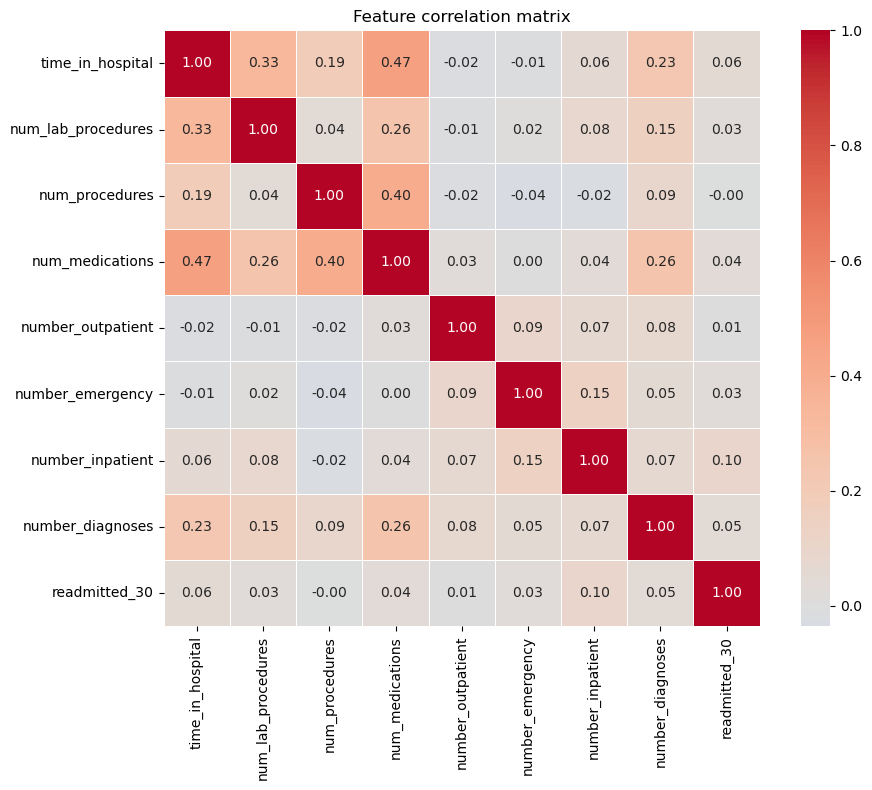

In [64]:
import seaborn as sns

numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                'num_medications', 'number_outpatient', 'number_emergency',
                'number_inpatient', 'number_diagnoses', 'readmitted_30']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

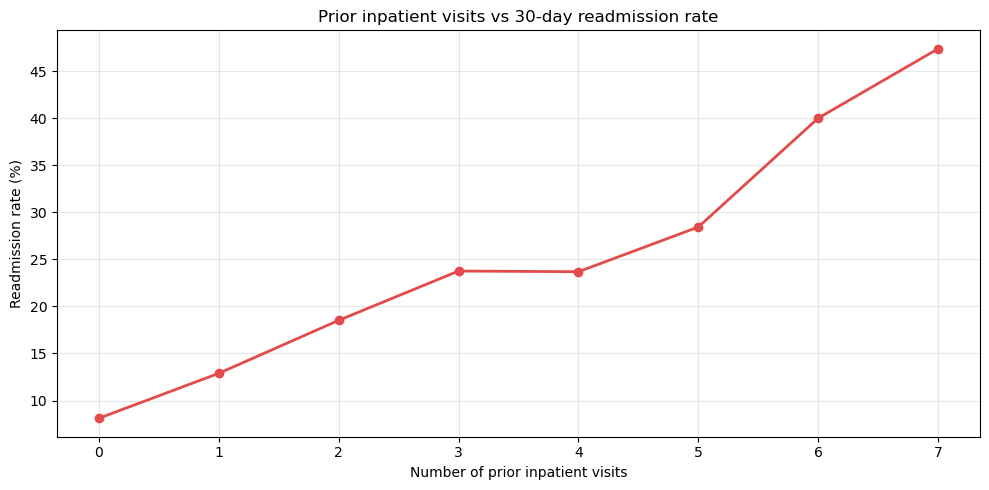

In [26]:
# Patients with more prior visits are much more likely to be readmitted
visit_rates = df.groupby('number_inpatient')['readmitted_30'].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(visit_rates.index[:8], visit_rates.values[:8],
         marker='o', color='#E24B4A', linewidth=2)
plt.title('Prior inpatient visits vs 30-day readmission rate')
plt.xlabel('Number of prior inpatient visits')
plt.ylabel('Readmission rate (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('readmission_by_visits.png', dpi=150)
plt.show()

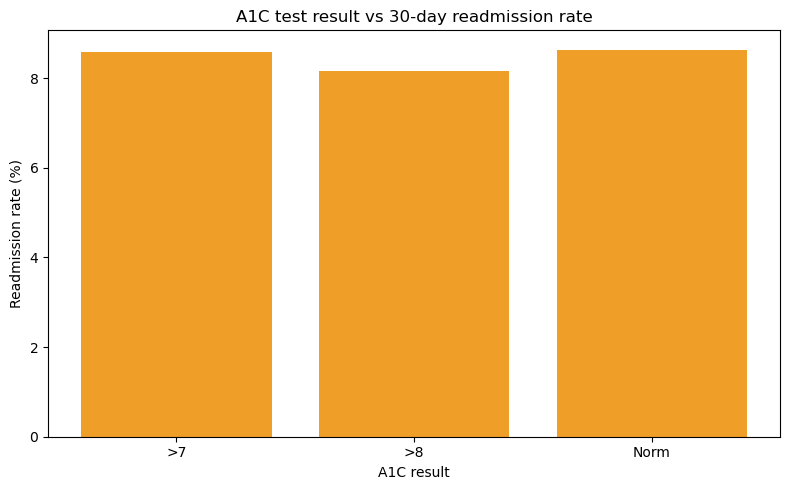

In [27]:
# A1C is a diabetes blood sugar test — higher = worse control
a1c_rates = df.groupby('A1Cresult')['readmitted_30'].mean() * 100

plt.figure(figsize=(8, 5))
plt.bar(a1c_rates.index, a1c_rates.values, color='#EF9F27')
plt.title('A1C test result vs 30-day readmission rate')
plt.xlabel('A1C result')
plt.ylabel('Readmission rate (%)')
plt.tight_layout()
plt.savefig('readmission_by_a1c.png', dpi=150)
plt.show()

In [28]:
import sqlite3

# Create connection first
conn = sqlite3.connect('readmission.db')

# Then save to it
df.to_sql('encounters', conn, if_exists='replace', index=False)
print("✅ Data saved to encounters table!")

✅ Data saved to encounters table!


In [65]:
import sqlite3

conn = sqlite3.connect('readmission.db')

query = """
SELECT admission_type, 
       COUNT(*) AS total_patients,
       SUM(readmitted_30) AS readmitted,
       ROUND(AVG(readmitted_30) * 100, 2) AS readmission_rate_pct
FROM encounters
GROUP BY admission_type
ORDER BY readmission_rate_pct DESC
"""

cohort_df = pd.read_sql_query(query, conn)
print(cohort_df)

  admission_type  total_patients  readmitted  readmission_rate_pct
0        Newborn               9           1                 11.11
1        Unknown            7893         735                  9.31
2      Emergency           35466        3252                  9.17
3         Urgent           12802        1148                  8.97
4       Elective           13785        1141                  8.28
5  Trauma Center              18           0                  0.00


In [29]:

query_highrisk = """
SELECT *
FROM encounters
WHERE number_inpatient >= 2
"""
high_risk = pd.read_sql_query(query_highrisk, conn)
print(f"High-risk cohort size: {len(high_risk)}")
print(f"Readmission rate: {high_risk['readmitted_30'].mean() * 100:.1f}%")

High-risk cohort size: 2397
Readmission rate: 21.5%


In [30]:
query_a1c = """
SELECT A1Cresult, insulin,
       COUNT(*) AS n,
       ROUND(AVG(readmitted_30) * 100, 2) AS readmission_rate_pct
FROM encounters
GROUP BY A1Cresult, insulin
HAVING COUNT(*) > 100
ORDER BY readmission_rate_pct DESC
"""

a1c_insulin = pd.read_sql_query(query_a1c, conn)
print(a1c_insulin)
conn.close()

   A1Cresult insulin      n  readmission_rate_pct
0       None    Down   5456                 11.00
1         >7    Down    295                 10.51
2       None      Up   4908                 10.13
3         >8      Up   1214                  9.72
4       None  Steady  17380                  9.64
5         >7  Steady    937                  9.28
6         >8    Down   1138                  9.14
7       Norm      No   1802                  9.10
8       Norm      Up    350                  8.57
9       Norm    Down    432                  8.56
10      None      No  29384                  8.26
11        >8      No   1744                  8.08
12        >7      No   1328                  7.98
13      Norm  Steady   1157                  7.95
14        >7      Up    305                  7.21
15        >8  Steady   2143                  6.81


In [31]:
df.drop(columns=['weight', 'payer_code'], inplace=True, errors='ignore')

In [32]:
df.replace('?', pd.NA, inplace=True)

# Safe drop — won't error if columns are already missing
df.drop(columns=['weight', 'payer_code'], inplace=True, errors='ignore')

age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age_mid'] = df['age'].map(age_map)

df_model = pd.get_dummies(df, columns=['race', 'gender', 'admission_type',
                                        'A1Cresult', 'diag_category'], drop_first=True)

In [39]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df_model.columns
                if c not in ['readmitted_30', 'readmitted', 
                             'patient_nbr', 'encounter_id']]

X = df_model[feature_cols].fillna(0)
y = df_model['readmitted_30']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Positive rate: {y.mean():.2%}")
print(f"Features used: {len(feature_cols)}")

Train: (55978, 63), Test: (13995, 63)
Positive rate: 8.97%
Features used: 63


In [ ]:
X_train.dtypes

In [ ]:
X_train.isnull().sum().sum()

In [ ]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df_model.columns
                if c not in ['readmitted_30', 'readmitted', 'patient_nbr',
                              'encounter_id', 'age', 'admission_type_id',
                              'diag_1', 'diag_2', 'diag_3']]

X = df_model[feature_cols].fillna(0)
y = df_model['readmitted_30']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Positive rate: {y.mean():.2%}")

In [50]:
from imblearn.over_sampling import SMOTE
import numpy as np

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {dict(zip(*np.unique(y_train_res, return_counts=True)))}")

Before SMOTE: {0: 50956, 1: 5022}
After SMOTE:  {0: 50956, 1: 50956}


In [49]:
# Drop columns that can't be converted to numbers
cols_to_drop = []
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        cols_to_drop.append(col)

print(f"Dropping {len(cols_to_drop)} non-numeric columns: {cols_to_drop}")

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"✅ Done! Final shape: {X_train.shape}")

Dropping 0 non-numeric columns: []
✅ Done! Final shape: (55978, 63)


In [ ]:
feat_imp = pd.Series(clf.feature_importances_, index=X.columns)
top20 = feat_imp.sort_values(ascending=True).tail(20)

plt.figure(figsize=(10, 7))
plt.barh(top20.index, top20.values, color='#5DCAA5')
plt.title('Top 20 features — Random Forest')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [51]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train_res, y_train_res)
print("Model trained successfully!")
print(f"Trained on {len(X_train_res)} samples (SMOTE balanced)")

Model trained successfully!
Trained on 101912 samples (SMOTE balanced)


In [59]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# Use Gradient Boosting instead of Random Forest
clf2 = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
clf2.fit(X_train, y_train)

y_prob2 = clf2.predict_proba(X_test)[:, 1]
y_pred2 = (y_prob2 >= 0.08).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred2))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob2):.3f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.59      0.73     12740
           1       0.13      0.61      0.21      1255

    accuracy                           0.59     13995
   macro avg       0.53      0.60      0.47     13995
weighted avg       0.87      0.59      0.68     13995

ROC-AUC Score: 0.645


In [ ]:
feat_imp = pd.Series(clf.feature_importances_, index=X_train.columns)
top20 = feat_imp.sort_values(ascending=True).tail(20)

plt.figure(figsize=(10, 7))
plt.barh(top20.index, top20.values, color='#5DCAA5')
plt.title('Top 20 features — Random Forest')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [61]:
risk_scores = X_test.copy()
risk_scores['readmitted_30_actual'] = y_test.values
risk_scores['risk_score'] = y_prob

risk_scores[['risk_score', 'readmitted_30_actual']].to_csv('patient_risk_scores.csv', index=False)
print("Risk scores saved to patient_risk_scores.csv!")
print(f"High-risk patients (score > 0.3): {(y_prob > 0.3).sum()}")

Risk scores saved to patient_risk_scores.csv!
High-risk patients (score > 0.3): 6095


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [63]:
import pandas as pd

# Create risk scores from scratch
risk_scores = X_test.copy()
risk_scores['readmitted_30_actual'] = y_test.values
risk_scores['risk_score'] = y_prob2
risk_scores['encounter_id'] = df.loc[X_test.index, 'encounter_id'].values

# Create cohort analysis
cohort_df = df.groupby('admission_type').agg(
    total_patients=('readmitted_30', 'count'),
    readmitted=('readmitted_30', 'sum'),
    readmission_rate=('readmitted_30', 'mean')
).reset_index()

# Save all 3 files
cohort_df.to_csv('cohort_analysis.csv', index=False)
risk_scores[['encounter_id', 'risk_score', 'readmitted_30_actual']].to_csv('patient_risk_scores.csv', index=False)
df.to_csv('cleaned_diabetic_data.csv', index=False)

print("✅ All 3 files saved!")
print("  1. cleaned_diabetic_data.csv")
print("  2. cohort_analysis.csv")
print("  3. patient_risk_scores.csv")

✅ All 3 files saved!
  1. cleaned_diabetic_data.csv
  2. cohort_analysis.csv
  3. patient_risk_scores.csv


In [ ]:
import os
print(os.getcwd())

In [ ]:
import os

files = ['cleaned_diabetic_data.csv', 'cohort_analysis.csv', 'patient_risk_scores.csv']

for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"✅ Found: {f} ({size:.1f} KB)")
    else:
        print(f"❌ Missing: {f}")

In [ ]:
print(df.shape)
print(X_test.shape)
print(risk_scores.shape)

In [ ]:
# FINAL SAVE — with encounter_id confirmed
import os
import pandas as pd

# Rebuild risk_scores cleanly with encounter_id
final_risk = pd.DataFrame()
final_risk['encounter_id'] = df.loc[X_test.index, 'encounter_id'].values
final_risk['risk_score'] = y_prob
final_risk['readmitted_30_actual'] = y_test.values

# Save all 3 files
cohort_df.to_csv('cohort_analysis.csv', index=False)
final_risk.to_csv('patient_risk_scores.csv', index=False)
df.to_csv('cleaned_diabetic_data.csv', index=False)

# Verify
for f in ['cleaned_diabetic_data.csv', 'cohort_analysis.csv', 'patient_risk_scores.csv']:
    size = os.path.getsize(f) / 1024
    print(f"✅ {f} ({size:.1f} KB)")

print("\nSample risk scores:")
print(final_risk.head())
print(f"\nHigh Risk (>=0.15): {(final_risk['risk_score'] >= 0.15).sum()}")
print(f"Medium Risk (0.08-0.15): {((final_risk['risk_score'] >= 0.08) & (final_risk['risk_score'] < 0.15)).sum()}")
print(f"Low Risk (<0.08): {(final_risk['risk_score'] < 0.08).sum()}")